In [2]:
%pip install scikit-image

   ---------------------------------------- 0.0/11.9 MB ? eta -:--:--
   ---------------------------------------- 0.0/11.9 MB ? eta -:--:--
    --------------------------------------- 0.3/11.9 MB ? eta -:--:--
   -- ------------------------------------- 0.8/11.9 MB 2.5 MB/s eta 0:00:05
   ----- ---------------------------------- 1.6/11.9 MB 3.0 MB/s eta 0:00:04
   ------- -------------------------------- 2.4/11.9 MB 3.3 MB/s eta 0:00:03
   ---------- ----------------------------- 3.1/11.9 MB 3.5 MB/s eta 0:00:03
   -------------- ------------------------- 4.2/11.9 MB 3.7 MB/s eta 0:00:03
   ----------------- ---------------------- 5.2/11.9 MB 3.9 MB/s eta 0:00:02
   ---------------------- ----------------- 6.6/11.9 MB 4.2 MB/s eta 0:00:02
   ------------------------- -------------- 7.6/11.9 MB 4.3 MB/s eta 0:00:02
   ----------------------------- ---------- 8.7/11.9 MB 4.5 MB/s eta 0:00:01
   ---------------------------------- ----- 10.2/11.9 MB 4.6 MB/s eta 0:00:01
   ----------------

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.


In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from skimage import data, exposure, io
from skimage.exposure import match_histograms

io.imsave('moon.png', data.moon())
io.imsave('chelsea.png', data.chelsea())
io.imsave('rocket.png', data.rocket())

print("Libraries imported and original images saved successfully.")

Libraries imported and original images saved successfully.


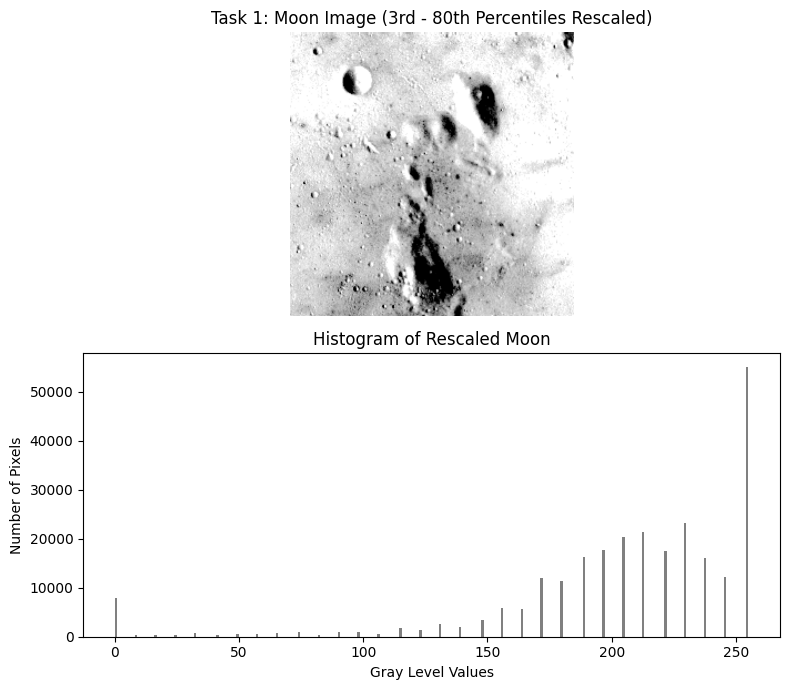

In [4]:

moon_img = data.moon()

p3, p80 = np.percentile(moon_img, (3, 80))

moon_rescaled = exposure.rescale_intensity(moon_img, in_range=(p3, p80))

fig, axes = plt.subplots(2, 1, figsize=(8, 7))

axes[0].imshow(moon_rescaled, cmap='gray')
axes[0].set_title('Task 1: Moon Image (3rd - 80th Percentiles Rescaled)')
axes[0].axis('off')

axes[1].hist(moon_rescaled.ravel(), bins=256, range=(0, 255), color='gray')
axes[1].set_title('Histogram of Rescaled Moon')
axes[1].set_xlabel('Gray Level Values')
axes[1].set_ylabel('Number of Pixels')

plt.tight_layout()
plt.savefig('task1_output.png', dpi=300)
plt.show()

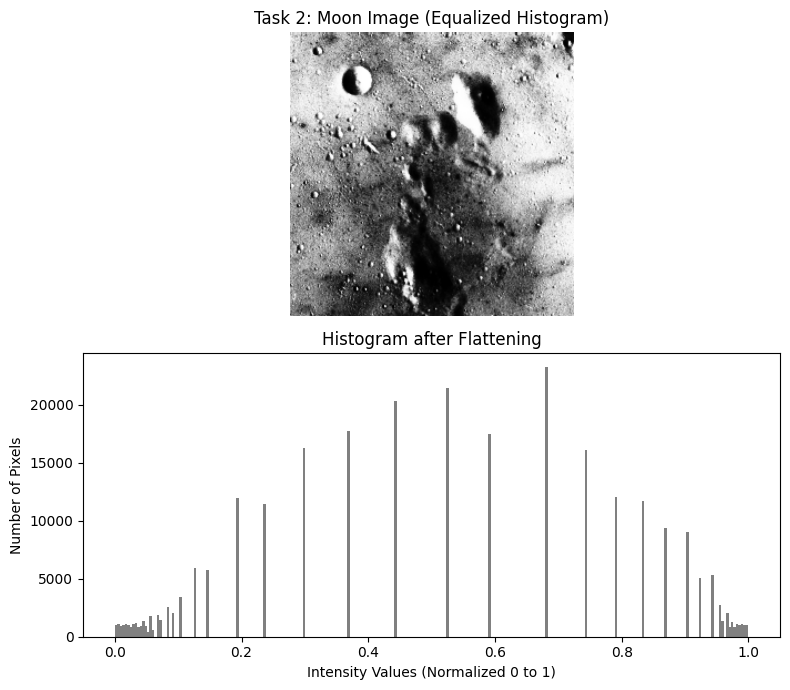

In [5]:
moon_equalized = exposure.equalize_hist(moon_img)

fig, axes = plt.subplots(2, 1, figsize=(8, 7))

axes[0].imshow(moon_equalized, cmap='gray')
axes[0].set_title('Task 2: Moon Image (Equalized Histogram)')
axes[0].axis('off')

axes[1].hist(moon_equalized.ravel(), bins=256, range=(0, 1), color='gray')
axes[1].set_title('Histogram after Flattening')
axes[1].set_xlabel('Intensity Values (Normalized 0 to 1)')
axes[1].set_ylabel('Number of Pixels')

plt.tight_layout()
plt.savefig('task2_output.png', dpi=300)
plt.show()

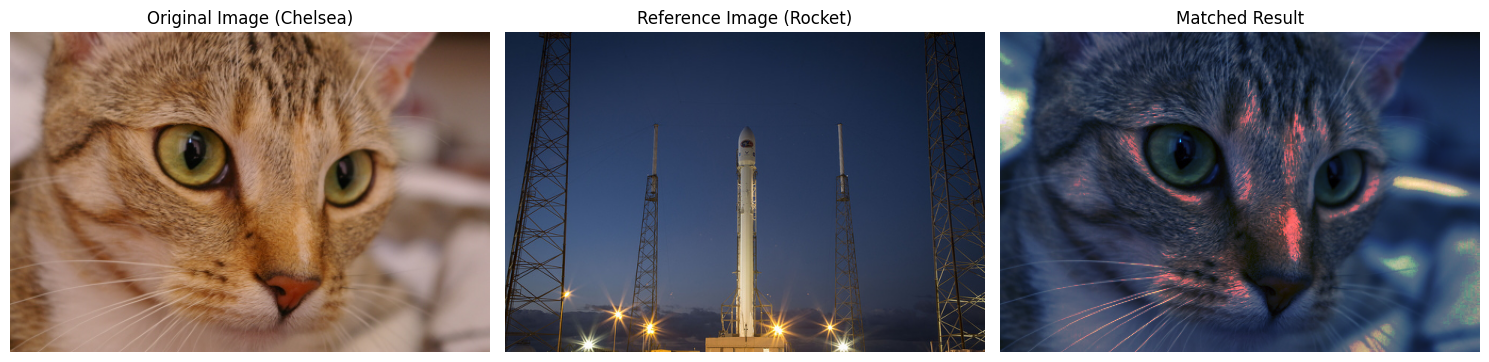

In [6]:
image = data.chelsea()      
reference = data.rocket()   

matched = match_histograms(image, reference, channel_axis=-1)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(image)
axes[0].set_title('Original Image (Chelsea)')
axes[0].axis('off')

axes[1].imshow(reference)
axes[1].set_title('Reference Image (Rocket)')
axes[1].axis('off')

axes[2].imshow(matched)
axes[2].set_title('Matched Result')
axes[2].axis('off')

plt.tight_layout()
plt.savefig('task3_output.png', dpi=300)
plt.show()